In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

In [106]:
import random

In [2]:
names = []
with open('names.txt', 'r') as f:
    for name in f.readlines():
        names.append(name[:-1])

## Implementing the MLP as per Bengio's paper
This is a charecter level architecture. The model takes in the trigram as input and predicts the next word.

In [3]:
# create an index from charecter to index an reverse
special_char = '.'
chars = set(list(''.join(names)) + [special_char])
stoi = {c:i for i, c in enumerate(sorted(chars))}
itos = {i:c for c, i in stoi.items()}
num_chars = len(stoi)

In [4]:
stoi

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [5]:
# create the trigrams and the targets
X = []
Y = []
block_size = 3
for name in names:
    name = [special_char] + list(name) + [special_char]
    for i in range(1, len(name)):
        end_idx = i
        start_idx = end_idx - block_size
        input_block = [max(idx, 0) for idx in range(start_idx, end_idx)]
        target_char = name[end_idx]
        input_ngram = [name[idx] for idx in input_block]
        Y.append(stoi[target_char])
        X.append([stoi[c] for c in input_ngram])
        # print(''.join(input_ngram) , "-->", target_char)


In [6]:
X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
print(f'Number of training example = {len(X)}')

Number of training example = 228145


In [9]:
# split the data into train, val and test
train_frac = 0.9
val_frac = 0.05
test_frac = 0.05
n1  = int(len(X)*train_frac)
n2 = n1 + int(len(X)*val_frac)

print(f'Number of train example = {n1}')
print(f'Number of val example = {n2 - n1}')
print(f'Number of test example = {len(X) - n2}')

Xtr, Ytr = X[:n1], Y[:n1]
Xval, Yval = X[n1:n2], Y[n1:n2]
Xtest, Ytest = X[n2:], Y[n2:]

Number of train example = 205330
Number of val example = 11407
Number of test example = 11408


### Build a neural network on the lines of Bengio's paper


In [109]:
# initialize the nn
num_emb_dim = 5
g = torch.Generator().manual_seed(212319023235)
C = torch.randn((num_chars, num_emb_dim), generator=g)
W1 = torch.randn((block_size*num_emb_dim, 50), generator=g)
b1 = torch.randn(50, generator=g)
W2 = torch.randn((50, num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [p.requires_grad_() for p in [C, W1, b1, W2, b2]]
# x = X[:2]
# x.shape
# C
# x1 = C[x]
# x1.shape # batch size, ngram, emb_dim
# # concatenate
# x2 = x1.view(x1.shape[0], block_size*num_emb_dim)
# x2.shape
# W1.shape
# (x2@W1).shape
# b1.shape
# (x2@W1 + b1).shape
# # transform the embedding output
# x2.shape
# x3 = (x2@W1 + b1)
# # apply the non linearity
# x4 = torch.tanh(x3)
# # apply next transformation to output the logits
# x5 = x3@W2
# # apply the softmax to output the probability
# output = F.softmax(x5, dim=-1)
# # compiling the forward pass together
# x = X[:2]
# x1 = C[x]
# # concatenate
# x2 = x1.view(x1.shape[0], block_size*num_emb_dim)
# # transform the embedding output
# x2.shape
# x3 = (x2@W1 + b1)
# # apply the non linearity
# x4 = torch.relu(x3)
# # apply next transformation to output the logits
# x5 = x3@W2
# # apply the softmax to output the probability
# output = F.softmax(x5, dim=-1)

In [110]:
def forward(x):
    # forward pass on the batch
    x1 = C[x]
    # concatenate
    x2 = x1.view(x1.shape[0], block_size*num_emb_dim)
    # transform the embedding output
    x2.shape
    x3 = (x2@W1 + b1)
    # apply the non linearity
    x4 = torch.tanh(x3)
    # apply next transformation to output the logits
    logits = x3@W2 + b2
    return logits
    

In [ ]:
trn_steps = []
trn_loss  =[]
batch_size = 32
step = 0

In [ ]:
# finding the best learning rate
lri = torch.linspace(-3, 0, 1000)
lrs = torch.pow(10, lri)

In [ ]:
# train the nueral net on the train set
for i in range(1000):
    # create a random mini batch
    ix = torch.randint(0, len(Xtr), (batch_size, ))
    x = Xtr[ix, :]
    y = Ytr[ix]
    # zero grad the params
    for param in params:
        param.grad = None
    
    # forward pass 
    logits = forward(x)
    # compute the loss
    nll = F.cross_entropy(logits, y)
    # print(f"Loss = {nll}")
    nll.backward()

    lr = lrs[i]

    # update the parameters
    for param in params:
        param.data += -lr*param.grad

    trn_steps.append(step)
    trn_loss.append(nll.log().item())
    step += 1


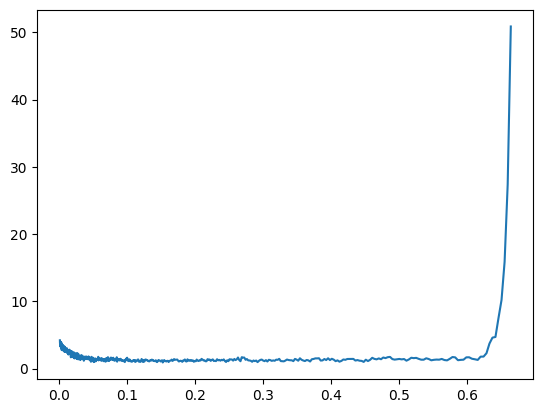

In [115]:
plt.plot(lrs, trn_loss)

In [236]:
trn_steps = []
trn_loss  =[]
batch_size = 64
step = 0

In [237]:
num_emb_dim = 5
g = torch.Generator().manual_seed(212319023235)
C = torch.randn((num_chars, num_emb_dim), generator=g)
W1 = torch.randn((block_size*num_emb_dim, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, num_chars), generator=g)
b2 = torch.randn(num_chars, generator=g)

params = [p.requires_grad_() for p in [C, W1, b1, W2, b2]]

In [242]:
# train the nueral net on the train set
for _ in range(50000):
    # create a random mini batch
    ix = torch.randint(0, len(Xtr), (batch_size, ))
    x = Xtr[ix, :]
    y = Ytr[ix]
    # zero grad the params
    for param in params:
        param.grad = None
    
    # forward pass 
    logits = forward(x)
    # compute the loss
    nll = F.cross_entropy(logits, y)
    # print(f"Loss = {nll}")
    nll.backward()

    # update the parameters
    for param in params:
        param.data += -0.01*param.grad

    trn_steps.append(step)
    trn_loss.append(nll.log().item())
    step += 1


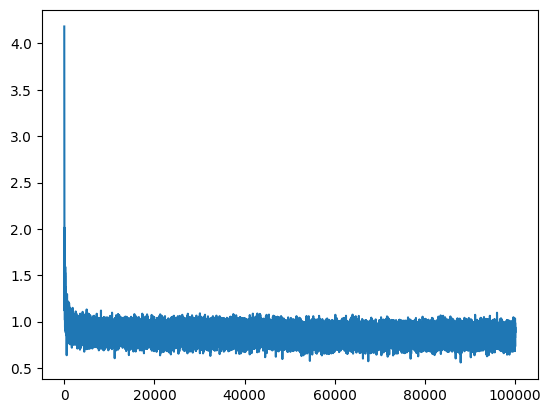

In [243]:
plt.plot(trn_steps, trn_loss)

In [244]:
# performance on the train data
logits = forward(Xtr)
print(f'Train Loss = {F.cross_entropy(logits, Ytr)}')
    

Train Loss = 2.348886013031006


In [245]:
# preformance on val set
logits = forward(Xval)
print(f'Train Loss = {F.cross_entropy(logits, Yval)}')

Train Loss = 2.506073236465454


In [148]:
# vizualize the embeddings
from sklearn.decomposition import PCA

In [149]:
pca = PCA(n_components=2)
pca.fit(C.detach().cpu().numpy())

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


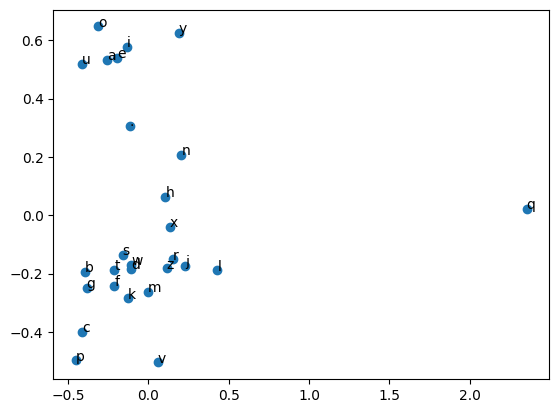

In [150]:
projected = pca.transform(C.detach().cpu().numpy())
plt.scatter(projected[:, 0], projected[:, 1])
for i in range(projected.shape[0]):
    plt.text(projected[i, 0], projected[i, 1], itos[i])


In [266]:
# sample from the model
for _ in  range(10):
    start_idx = random.randint(1, num_chars - 1)
    output = itos[start_idx]
    start_idx = torch.tensor(start_idx).view(-1, 1)
    while start_idx.shape[1] < block_size:
        start_idx = torch.hstack((torch.tensor([[0]]), start_idx))

    while True:
        y_pred = forward(start_idx)
        y_probs = F.softmax(y_pred, dim = 1)
        ipred = torch.multinomial(y_probs, num_samples=1, generator=g).item()
        cpred = itos[ipred]
        output += cpred
        if cpred == '.':
            break
        # update the input  
        start_idx = torch.hstack((start_idx, torch.tensor(ipred).view(-1, 1)))[:, 1:]

    print(output)
    


ken.
zai.
ymi.
ven.
jeci.
iah.
xefit.
percrijsha.
mulaneli.
sanie.
